## Objective:
`The objective of this project is to analyze Pakistan startup data to uncover trends in startup growth, industry distribution, funding patterns, and operational status.
`
## Author:
` Eman khalil`

### 1. Load Libraries and Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("final_pak_startups_for_analysis.csv")

df.head()

,startup_name,active_opinion_by_cms,location,hq,founded_date,industry_vertical,horizontal,operating_status,funding_status,employees,funding_round_1_investment,founder_round_1_investors,funding_round_1_date,funding_round_2_investment,founder_round_2_investors,funding_round_2_date,primary_industry,city,founders
0,Eat Mubarak,Y,"Karachi,Pakistan",Asia-Pacific,2018-01-01,Services,"Ecommerce , online Delivery",Active,Seed,11 to 50,500000.0,Yusuf Jan,2018-01-11,700000.0,Karavan,2019-01-02,Services,Karachi,"Ahmed Alvi, Hyder Abbas, Mian Ahmad"
1,Finja,Y,Lahore,Asia-Pacific,2015-01-01,"Financial Exchanges, Financial Services","Mobile Payments, Software",Active,Early Stage Venture,101 to 250,1000000.0,Vostok Emerging Finance,2016-08-02,1500000.0,"Gray Mackenzie Engineering Services, Vostok Em...",2017-10-18,Financial Exchanges,Lahore,"Monis Rehman, Qasif Shahid, Umer Munawar"
2,Airlift Technologies,Y,"Lahore, Punjab, Pakistan",Asia-Pacific,2018-01-01,Transportation,Mobile App,Active,Early Stage Venture,1 to 10,2200000.0,"Fatima Ventures, Indus Valley Capital, Fatima ...",2019-06-08,12000000.0,"Indus Valley Capital, First Round Capital, Fat...",2019-02-11,Transportation,Lahore,"Usman Gul, Ahmed Ayub"
3,DealSmash,NaN,Islamabad,Asia-Pacific,NaN,"Retail, Artificial Intelligence","Analytics, ,Artificial Intelligence",Active,Seed,1 to 10,8800000.0,National ICT R&D Fund,2017-05-15,150000.0,Al-Hilal Securties Advisors,2018-02-27,Retail,Islamabad,"Ahsan Vaqar Hundal, Ali Hasnain, Hamza Iftikhar"
4,Tajir,Y,"Lahore, Pakistan",Asia-Pacific,2018-01-01,Retail,"B2B, Ecommerce, Marketplace",Active,Seed,11 to 50,150000.0,"Y Combinator , Matt Caspari",2020-03-15,1800000.0,"Fatima Gobi Ventures, Golden Gate, Pioneer Fun...",2020-05-06,Retail,Lahore,"Babar Khan, Ismail Khan"


### 2. Data Overview

In [3]:
df.shape

(103, 19)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   startup_name                103 non-null    object 
 1   active_opinion_by_cms       38 non-null     object 
 2   location                    103 non-null    object 
 3   hq                          103 non-null    object 
 4   founded_date                47 non-null     object 
 5   industry_vertical           99 non-null     object 
 6   horizontal                  68 non-null     object 
 7   operating_status            103 non-null    object 
 8   funding_status              103 non-null    object 
 9   employees                   90 non-null     object 
 10  funding_round_1_investment  69 non-null     float64
 11  founder_round_1_investors   55 non-null     object 
 12  funding_round_1_date        98 non-null     object 
 13  funding_round_2_investment  19 non-

In [5]:
df.describe()

,funding_round_1_investment,funding_round_2_investment
count,6.900000e+01,1.900000e+01
mean,3.007297e+06,1.682221e+06
std,1.261436e+07,3.110499e+06
min,3.000000e+03,2.200000e+03
25%,1.000000e+05,1.800000e+05
50%,2.200000e+05,6.800000e+05
75%,1.000000e+06,1.400000e+06
max,8.900000e+07,1.200000e+07


In [6]:
df.isnull().sum()

startup_name                   0
active_opinion_by_cms         65
location                       0
hq                             0
founded_date                  56
industry_vertical              4
horizontal                    35
operating_status               0
funding_status                 0
employees                     13
funding_round_1_investment    34
founder_round_1_investors     48
funding_round_1_date           5
funding_round_2_investment    84
founder_round_2_investors     89
funding_round_2_date          81
primary_industry               0
city                           0
founders                      15
dtype: int64

In [7]:
df.drop(columns=[
'funding_round_2_investment',
'founder_round_2_investors',
'funding_round_2_date'
], inplace=True)

## 3. Exploratory Data Analysis

### 1️⃣ Which City Has the Most Startups?

In [8]:
df['city'].value_counts()

city
Lahore        45
Karachi       31
Islamabad     22
Hyderabad      1
Sialkot        1
Gujrat         1
Faisalabad     1
Rawalpindi     1
Name: count, dtype: int64

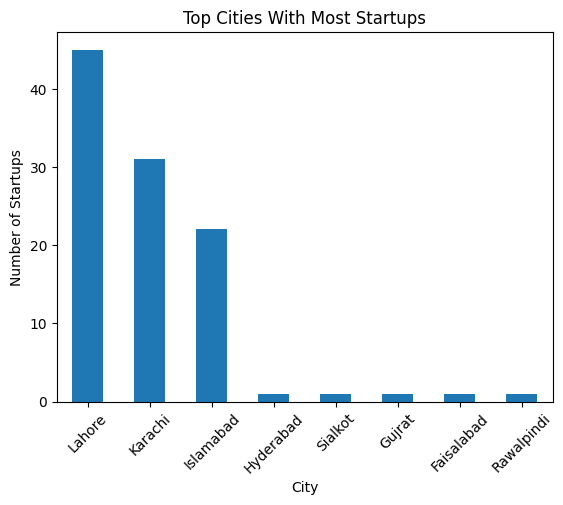

In [9]:
# Visualisation
df['city'].value_counts().head(10).plot(kind='bar')

plt.title("Top Cities With Most Startups")
plt.xlabel("City")
plt.ylabel("Number of Startups")
plt.xticks(rotation=45)
plt.show()

### 2️⃣ Which Industry Has the Most Startups?

In [ ]:
df['industry_vertical'].value_counts().head(10)

industry_vertical
Retail            9
E-Commerce        5
Health Care       3
Entertainment     3
Advertising       3
Logistics         3
Transportation    2
It Services       2
Education         2
Travel            2
Name: count, dtype: int64

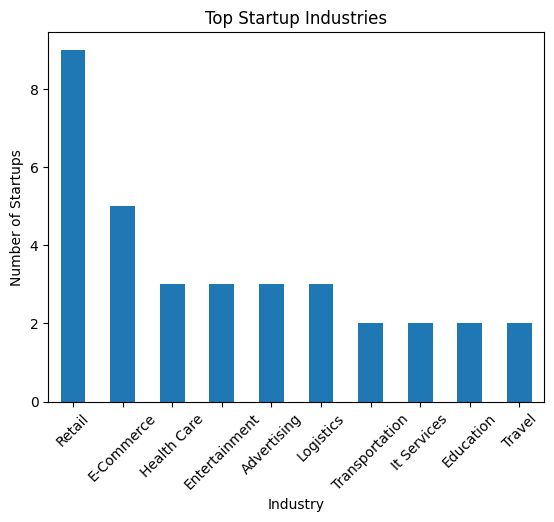

In [ ]:
# Visulisation
df['industry_vertical'].value_counts().head(10).plot(kind='bar')

plt.title("Top Startup Industries")
plt.xlabel("Industry")
plt.ylabel("Number of Startups")
plt.xticks(rotation=45)
plt.show()

### 3️⃣ Startup Growth by Year

In [12]:
# Extract year:
df['founded_year'] = pd.to_datetime(df['founded_date'], errors='coerce').dt.year

In [13]:
# Count startups per year:
df['founded_year'].value_counts().sort_index()

founded_year
2003.0    2
2004.0    1
2006.0    1
2010.0    1
2012.0    5
2013.0    3
2014.0    6
2015.0    8
2016.0    6
2017.0    6
2018.0    5
2019.0    3
Name: count, dtype: int64

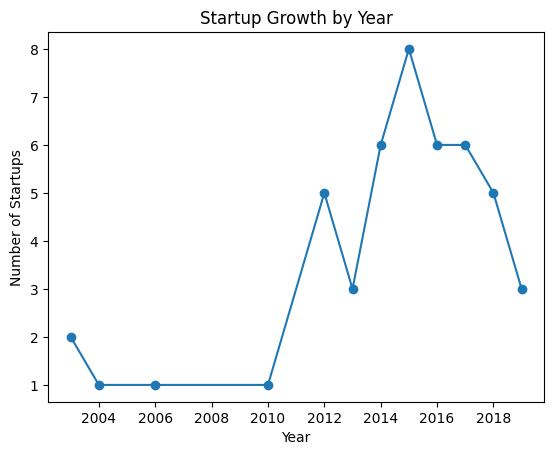

In [ ]:
# Visualisation
df['founded_year'].value_counts().sort_index().plot(kind='line', marker='o')

plt.title("Startup Growth by Year")
plt.xlabel("Year")
plt.ylabel("Number of Startups")
plt.show()

### 4️⃣ Operating Status (Active vs Closed)

In [15]:
df['operating_status'].value_counts()

operating_status
Active    103
Name: count, dtype: int64

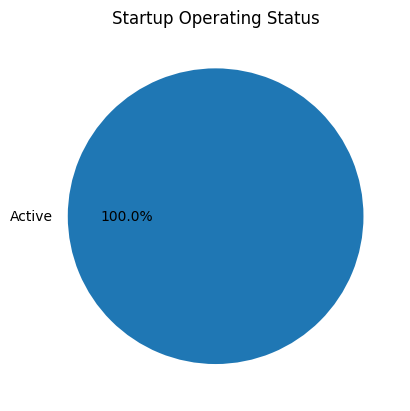

In [ ]:
# Visualisation
df['operating_status'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Startup Operating Status")
plt.ylabel("")
plt.show()

### 5️⃣ Average Funding Per Industry

In [17]:
df.groupby('industry_vertical')['funding_round_1_investment'].mean().sort_values(ascending=False)

industry_vertical
Transportation                     29600000.0
Retail                             11739375.0
Retail, Artificial Intelligence     8800000.0
Logistics                           7800000.0
Career Planning                     6500000.0
                                      ...    
Iot                                       NaN
Local Advertising                         NaN
Management                                NaN
Medical                                   NaN
Workspace                                 NaN
Name: funding_round_1_investment, Length: 71, dtype: float64

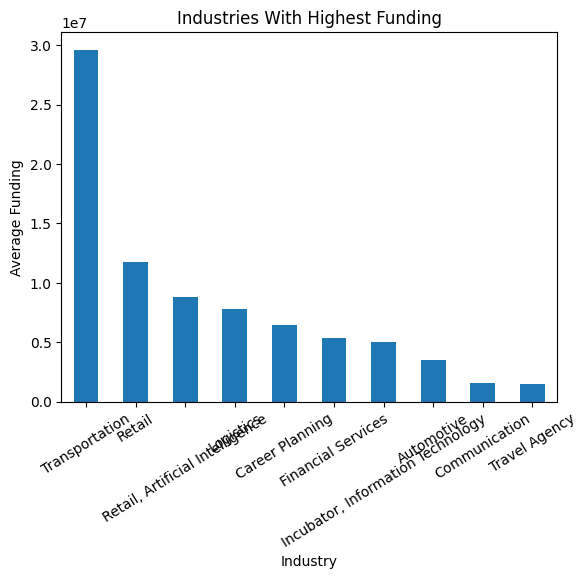

In [ ]:
# Visualisation
df.groupby('industry_vertical')['funding_round_1_investment'].mean().sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Industries With Highest Funding")
plt.xlabel("Industry")
plt.ylabel("Average Funding")
plt.xticks(rotation=32)
plt.show()

## Insights from the data:

1. Karachi and Lahore dominate the startup ecosystem.

2. Fintech and E-commerce are the most common industries.

3. Startup creation increased significantly after 2015.

4. Most startups are currently active.

5. Some industries attract significantly higher funding.